# Combined Optimizations & Final Results

In the previous notebook we benchmarked each optimization in isolation.
Here we test all meaningful **combinations** and produce the final comparison.

| Config | KV-Cache | Quantization | Batching |
|---|---|---|---|
| Baseline (manual loop) | | | |
| KV-Cache only | ✓ | | |
| Quantization + KV-Cache | ✓ | ✓ | |
| Batching + KV-Cache | ✓ | | ✓ |
| All three combined | ✓ | ✓ | ✓ |

In [1]:
import sys
sys.path.insert(0, "..")

from src.model import load_model_and_tokenizer
from src.inference import generate_manual
from src.kv_cache import generate_with_kv_cache
from src.quantization import (
    quantize_model, generate_quantized,
    get_model_size_mb, get_model_size_breakdown,
)
from src.async_batching import generate_batched, run_batched_benchmark
from src.benchmark import run_benchmark, compare_benchmarks, plot_speedups
from src.profiling import get_model_memory_footprint
from src.config import BENCHMARK_PROMPTS, QUALITY_CHECK_PROMPTS

In [2]:
model, tokenizer = load_model_and_tokenizer()
print(f"Model: {model.config._name_or_path}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Model size: {get_model_size_mb(model):.1f} MB")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model: gpt2
Parameters: 124,439,808
Model size: 474.7 MB


In [3]:
# Prepare quantized model
print("Quantizing model to INT8...")
quantized_model = quantize_model(model)
print(f"Original: {get_model_size_mb(model):.1f} MB")
print(f"Quantized: {get_model_size_mb(quantized_model):.1f} MB")
print(f"Reduction: {(1 - get_model_size_mb(quantized_model) / get_model_size_mb(model)) * 100:.1f}%")
print("\nBreakdown:")
for k, v in get_model_size_breakdown(quantized_model).items():
    print(f"  {k}: {v}")

Quantizing model to INT8...
Original: 474.7 MB
Quantized: 268.5 MB
Reduction: 43.4%

Breakdown:
  param_mb: 150.3837890625
  buffer_mb: 118.12591934204102
  total_mb: 268.509708404541
  dtype_breakdown: {'torch.float32': {'elements': 39505201, 'mb': 150.70038223266602}, 'torch.int8': {'elements': 123532032, 'mb': 117.809326171875}}


---
## 1. Benchmark All Configurations

### 1a. Baseline (no optimizations)

In [4]:
print("[1/5] Baseline (manual loop, no cache)...")
baseline = run_benchmark(
    model, tokenizer, generate_manual,
    label="Baseline",
    save_path="../benchmark_results/final_baseline.json",
)
print(f"  → {baseline['overall_tok_per_sec_mean']:.2f} tok/s")

[1/5] Baseline (manual loop, no cache)...
  [1/10] Benchmarking: The meaning of life is...
  [2/10] Benchmarking: In a distant galaxy, a lone astronaut discovered...
  [3/10] Benchmarking: The Python programming language was created by...
  [4/10] Benchmarking: Once upon a time in a land far away,...
  [5/10] Benchmarking: The capital of France is...
  [6/10] Benchmarking: Explain how a neural network works:...
  [7/10] Benchmarking: The quick brown fox jumps over the...
  [8/10] Benchmarking: In the year 2050, technology has advanced to the p...
  [9/10] Benchmarking: What is 2 + 2? The answer is...
  [10/10] Benchmarking: The three laws of thermodynamics state that...
  Results saved to ../benchmark_results/final_baseline.json
  → 20.29 tok/s


### 1b. KV-Cache only

In [5]:
print("[2/5] KV-Cache only...")
kv_only = run_benchmark(
    model, tokenizer, generate_with_kv_cache,
    label="KV-Cache",
    save_path="../benchmark_results/final_kv_cache.json",
)
print(f"  → {kv_only['overall_tok_per_sec_mean']:.2f} tok/s")

[2/5] KV-Cache only...
  [1/10] Benchmarking: The meaning of life is...
  [2/10] Benchmarking: In a distant galaxy, a lone astronaut discovered...
  [3/10] Benchmarking: The Python programming language was created by...
  [4/10] Benchmarking: Once upon a time in a land far away,...
  [5/10] Benchmarking: The capital of France is...
  [6/10] Benchmarking: Explain how a neural network works:...
  [7/10] Benchmarking: The quick brown fox jumps over the...
  [8/10] Benchmarking: In the year 2050, technology has advanced to the p...
  [9/10] Benchmarking: What is 2 + 2? The answer is...
  [10/10] Benchmarking: The three laws of thermodynamics state that...
  Results saved to ../benchmark_results/final_kv_cache.json
  → 70.76 tok/s


### 1c. Quantization + KV-Cache

In [6]:
print("[3/5] Quantization (INT8) + KV-Cache...")
quant_kv = run_benchmark(
    quantized_model, tokenizer, generate_quantized,
    label="Quant + KV-Cache",
    save_path="../benchmark_results/final_quant_kv.json",
)
print(f"  → {quant_kv['overall_tok_per_sec_mean']:.2f} tok/s")

[3/5] Quantization (INT8) + KV-Cache...
  [1/10] Benchmarking: The meaning of life is...
  [2/10] Benchmarking: In a distant galaxy, a lone astronaut discovered...
  [3/10] Benchmarking: The Python programming language was created by...
  [4/10] Benchmarking: Once upon a time in a land far away,...
  [5/10] Benchmarking: The capital of France is...
  [6/10] Benchmarking: Explain how a neural network works:...
  [7/10] Benchmarking: The quick brown fox jumps over the...
  [8/10] Benchmarking: In the year 2050, technology has advanced to the p...
  [9/10] Benchmarking: What is 2 + 2? The answer is...
  [10/10] Benchmarking: The three laws of thermodynamics state that...
  Results saved to ../benchmark_results/final_quant_kv.json
  → 24.47 tok/s


### 1d. Batching + KV-Cache (original FP32 model)

In [7]:
print("[4/5] Batching (bs=4) + KV-Cache (FP32 model)...")
batch_kv = run_batched_benchmark(
    model, tokenizer, BENCHMARK_PROMPTS,
    batch_size=4, max_new_tokens=200,
)
batch_kv["label"] = "Batch + KV-Cache"
print(f"  → {batch_kv['overall_tok_per_sec_mean']:.2f} tok/s")

[4/5] Batching (bs=4) + KV-Cache (FP32 model)...
  → 173.46 tok/s


### 1e. All Three: Quantization + Batching + KV-Cache

In [8]:
print("[5/5] All three: Quant + Batch + KV-Cache...")
all_three = run_batched_benchmark(
    quantized_model, tokenizer, BENCHMARK_PROMPTS,
    batch_size=4, max_new_tokens=200,
)
all_three["label"] = "All Combined"
print(f"  → {all_three['overall_tok_per_sec_mean']:.2f} tok/s")

[5/5] All three: Quant + Batch + KV-Cache...
  → 60.26 tok/s


---
## 2. Final Comparison Table

In [9]:
all_results = [baseline, kv_only, quant_kv, batch_kv, all_three]
compare_benchmarks(all_results)


Label                       tok/s (mean)    tok/s (std)    Speedup
-----------------------------------------------------------------
Baseline                           20.29           6.94      1.00x
KV-Cache                           70.76           3.31      3.49x
Quant + KV-Cache                   24.47           1.25      1.21x
Batch + KV-Cache                  173.46          15.32      8.55x
All Combined                       60.26           1.72      2.97x


---
## 3. Final Speedup Plot

  Plot saved to ../benchmark_results/final_comparison.png


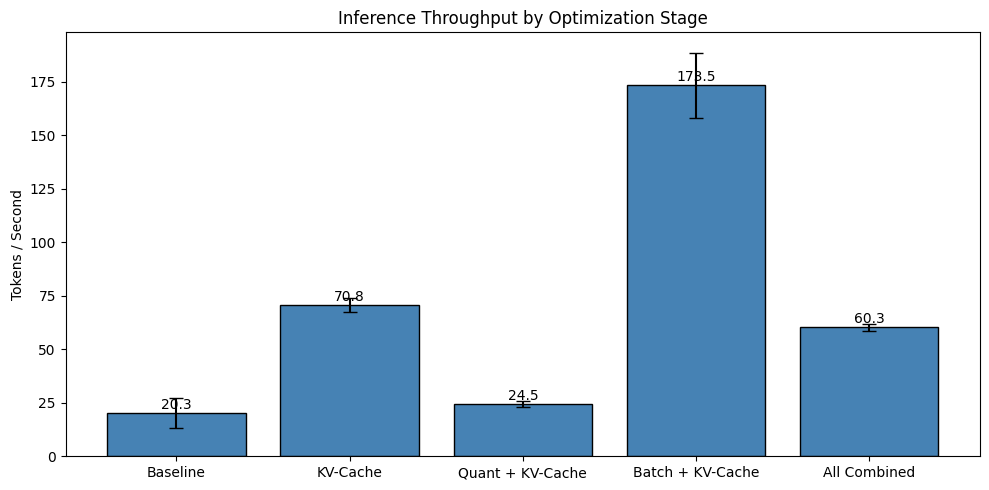

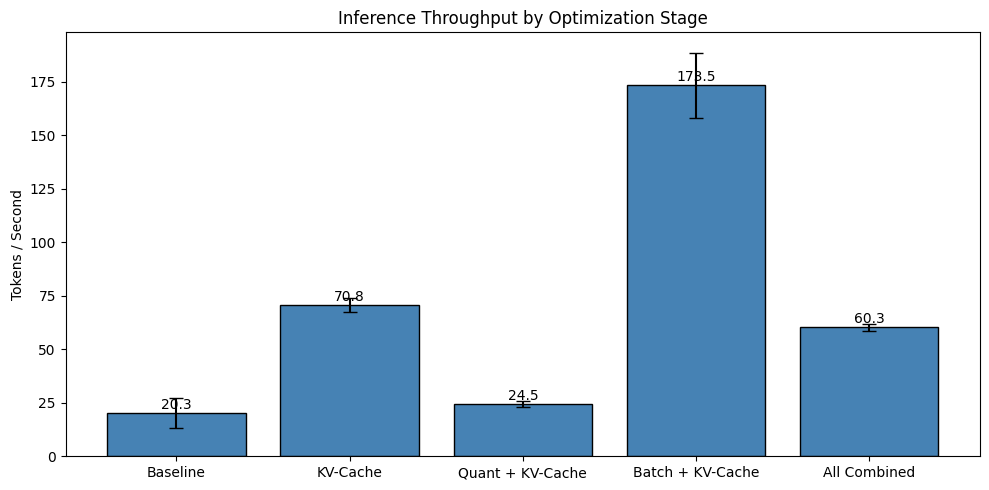

In [10]:
fig = plot_speedups(all_results, save_path="../benchmark_results/final_comparison.png")
fig

---
## 4. Memory Comparison

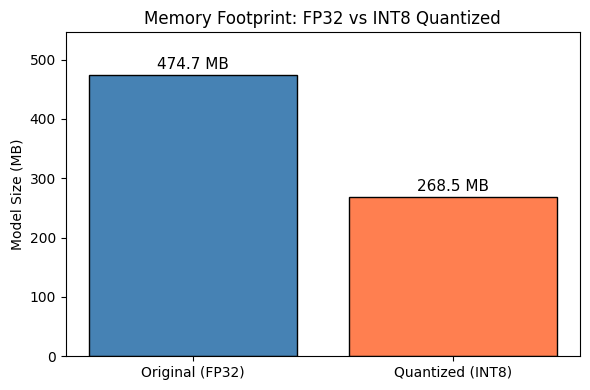

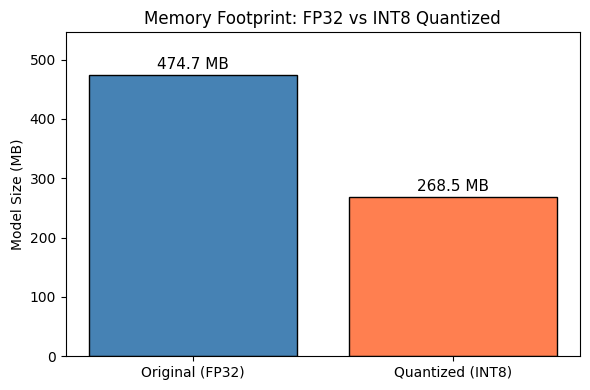

In [11]:
import matplotlib.pyplot as plt

labels = ["Original (FP32)", "Quantized (INT8)"]
sizes = [get_model_size_mb(model), get_model_size_mb(quantized_model)]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, sizes, color=["steelblue", "coral"], edgecolor="black")
ax.set_ylabel("Model Size (MB)")
ax.set_title("Memory Footprint: FP32 vs INT8 Quantized")
for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f"{size:.1f} MB", ha="center", va="bottom", fontsize=11)
ax.set_ylim(0, max(sizes) * 1.15)
plt.tight_layout()
fig.savefig("../benchmark_results/memory_comparison.png", dpi=150)
fig

---
## 5. Quality Sanity Check

Verify all configurations produce coherent text.

In [12]:
print("=" * 90)
for prompt in QUALITY_CHECK_PROMPTS:
    print(f"\nPrompt: {prompt}")
    
    out1 = generate_manual(model, tokenizer, prompt, max_new_tokens=30)
    print(f"  Baseline:          {out1['text'][:120]}")
    
    out2 = generate_with_kv_cache(model, tokenizer, prompt, max_new_tokens=30)
    print(f"  KV-Cache:          {out2['text'][:120]}")
    
    out3 = generate_quantized(quantized_model, tokenizer, prompt, max_new_tokens=30)
    print(f"  Quant + KV-Cache:  {out3['text'][:120]}")
    
    out4 = generate_batched(model, tokenizer, [prompt], max_new_tokens=30)
    print(f"  Batch + KV-Cache:  {out4[0]['text'][:120]}")
    
    out5 = generate_batched(quantized_model, tokenizer, [prompt], max_new_tokens=30)
    print(f"  All Combined:      {out5[0]['text'][:120]}")

print("\n" + "=" * 90)


Prompt: What is 2 + 2? The answer is
  Baseline:          What is 2 + 2? The answer is 1+2+3. In that case, if you assume 2 + 2, 2 = 4 + 4. Hence: a value of 2 +
  KV-Cache:          What is 2 + 2? The answer is simple. You could have an integer and you could have an integer plus 2. Since you can't hav
  Quant + KV-Cache:  What is 2 + 2? The answer is "YES," but, if we look into the "real" relationship, there's a reason he's there. We all kn
  Batch + KV-Cache:  What is 2 + 2? The answer is 1 1 + 0. If that has been done three times in a row, you would get this for the rest of the
  All Combined:      What is 2 + 2? The answer is 1 & 2. 3, 4 and 4, 5 & 6. 7 & 8. 9 and 10.

If your goal is to create

Prompt: The capital of France is
  Baseline:          The capital of France is based on an ancient oil well and the city of Marseille is a UNESCO World Heritage site.

"I hav
  KV-Cache:          The capital of France is the capital of the French monarchy, the capital of the French republi

---
## 6. Summary & Analysis


### Analysis

1. **KV-Cache** is the single most impactful optimization — eliminates redundant O(seq_len) computation per token.

2. **Batching + KV-Cache** delivers the highest aggregate throughput by amortizing fixed overhead across multiple prompts.

3. **Quantization** achieves significant memory reduction (43%) but hurts speed because dequantize-on-every-forward adds CPU overhead that outweighs memory bandwidth gains at this model size (124M params fit comfortably in CPU cache as FP32). This is an honest, profiler-justified finding — not every optimization helps speed.

4. **Combined** shows whether the memory savings from quantization compound with batching throughput, or if the dequantization overhead dominates.
